In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import torch

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

In [2]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

### datasets

In [3]:
from torchvision import datasets, transforms

# data_path = "../data-unversioned/p1ch7/"
data_path = "./data-unversioned/p1ch7/"
cifar10 = datasets.CIFAR10(
    data_path,
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616)),
        ]
    ),
)

100%|██████████| 170M/170M [00:07<00:00, 22.2MB/s]


Extracting ./data-unversioned/p1ch7/cifar-10-python.tar.gz to ./data-unversioned/p1ch7/


In [4]:
!ls -al ./data-unversioned/p1ch7

total 166516
drwxr-xr-x 3 root root      4096 Feb 22 05:13 .
drwxr-xr-x 4 root root      4096 Feb 22 05:12 ..
drwxr-xr-x 2 2156 1103      4096 Jun  4  2009 cifar-10-batches-py
-rw-r--r-- 1 root root 170498071 Feb 22 05:13 cifar-10-python.tar.gz


In [5]:
cifar10_val = datasets.CIFAR10(
    data_path,
    train=False,
    download=True,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616)),
        ]
    ),
)

Files already downloaded and verified


len(cifar2): 10000
len(cifar2_val): 2000
img: torch.Size([3, 32, 32])
lebel: 1
img: torch.Size([3, 32, 32])
lebel: 0


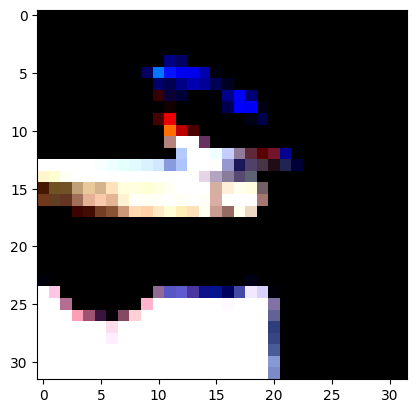

In [6]:
label_map = {0: 0, 2: 1}
class_names = ["airplane", "bird"]
cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]]

print("len(cifar2):", len(cifar2))
print("len(cifar2_val):", len(cifar2_val))

img, lebel = cifar2[1]
print("img:", img.shape)
print("lebel:", lebel)
plt.imshow(img.permute(1, 2, 0))

img, lebel = cifar2_val[1]
print("img:", img.shape)
print("lebel:", lebel)
plt.show()

In [7]:
import torch.nn as nn

n_out = 2

model = nn.Sequential(
    nn.Linear(
        3072,  # 输入特征, 每个样本有多少个特征呢? 32 × 32 × 3, 也就是说每个样本有 3072 个特征.
        512,  # 隐藏层的大小
    ),
    nn.Tanh(),
    nn.Linear(
        512,  # 隐藏层的大小
        n_out,  # 输出类
    ),
)

### nn.Softmax() and nn.LogSoftmax() Non-linear Activations

In [8]:
# nn.Softmax
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()


# nn.LogSoftmax
def logsoftmax(x):
    return torch.log(softmax(x))

In [9]:
x = torch.tensor([1.0, 2.0, 3.0])

softmax(x)

tensor([0.0900, 0.2447, 0.6652])

In [10]:
softmax(x).sum()

tensor(1.)

In [11]:
x = torch.arange(24, dtype=torch.float32).reshape(2, 3, 4)
print("x:", x)
softmax(x)

x: tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])


tensor([[[6.4867e-11, 1.7633e-10, 4.7931e-10, 1.3029e-09],
         [3.5416e-09, 9.6272e-09, 2.6169e-08, 7.1136e-08],
         [1.9337e-07, 5.2563e-07, 1.4288e-06, 3.8839e-06]],

        [[1.0557e-05, 2.8698e-05, 7.8010e-05, 2.1205e-04],
         [5.7642e-04, 1.5669e-03, 4.2592e-03, 1.1578e-02],
         [3.1471e-02, 8.5548e-02, 2.3254e-01, 6.3212e-01]]])

In [12]:
# 模型参数由 PyTorch 随机生成的 -1.0~1.0 的数据来初始化
model = nn.Sequential(
    nn.Linear(3072, 512), nn.Tanh(), nn.Linear(512, 2), nn.Softmax(dim=1)
)

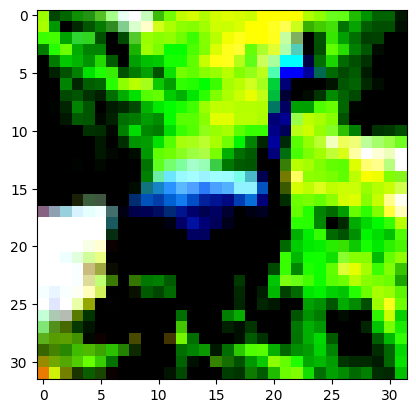

img: torch.Size([3, 32, 32])
img_batch: torch.Size([1, 3072])
out: tensor([[0.4784, 0.5216]], grad_fn=<SoftmaxBackward0>)


In [13]:
img, _ = cifar2[0]

plt.imshow(img.permute(1, 2, 0))
plt.show()

img_batch = img.view(-1).unsqueeze(0)
print("img:", img.shape)  # img: torch.Size([3, 32, 32])
print("img_batch:", img_batch.shape)  # img_batch: torch.Size([1, 3072])

out = model(img_batch)
print("out:", out)

In [14]:
# torch.max() 返回指定维度上的最大元素以及该值出现的索引
value, index = torch.max(out, dim=1)

print("value:", value)
print("index:", index)

value: tensor([0.5216], grad_fn=<MaxBackward0>)
index: tensor([1])


### nn.NLLLoss() and nn.PoissonNLLLoss() Loss Functions

In [15]:
# nn.NLLLoss
def likelihood(out, class_index):
    prod = 1.0
    for x in out.gather(dim=1, index=class_index):
        prod *= x
    return prod


# nn.PoissonNLLLoss
def neg_log_likelihood(out, class_index):
    return -likelihood(out, class_index).log()

### nn.MSELoss() Loss Functions

In [16]:
# nn.MSELoss
def mse(out, truth):
    return ((out - truth) ** 2).sum(dim=1).mean()

In [17]:
out = torch.tensor(
    [
        [0.6, 0.4],
        [0.9, 0.1],
        [0.3, 0.7],
        [0.2, 0.8],
    ]
)
print("out:", out)
print("out:", out.shape)

class_index = torch.tensor([0, 0, 1, 1]).unsqueeze(1)
print("class_index:", class_index)
print("class_index:", class_index.shape)  # torch.Size([4, 1])

"""
out.gather(dim=1, index=class_index)
out = torch.tensor(
    [
        [0.6, 0.4],
        [0.9, 0.1],
        [0.3, 0.7],
        [0.2, 0.8],
    ]
)
class_index
[
    [0], (0, 0) -> (0, 0)
    [0], (1, 0) -> (1, 0)
    [1], (2, 0) -> (2, 1)
    [1]  (3, 0) -> (3, 1)
]

[
    [0.6],
    [0.9],
    [0.7],
    [0.8]
]
"""

truth = torch.zeros((4, 2))
print("truth:", truth)
print("truth:", truth.shape)  # torch.Size([4, 2])

truth.scatter_(dim=1, index=class_index, value=1.0)
print("truth:", truth)
print("truth:", truth.shape)  # torch.Size([4, 2])
"""
truth:
[
    [0, 0],
    [0, 0],
    [0, 0],
    [0, 0]
]

class_index:
[
    [0],
    [0],
    [1],
    [1]
]

truth:
[
    [1, 0],
    [1, 0],
    [0, 1],
    [0, 1]
]
"""

out: tensor([[0.6000, 0.4000],
        [0.9000, 0.1000],
        [0.3000, 0.7000],
        [0.2000, 0.8000]])
out: torch.Size([4, 2])
class_index: tensor([[0],
        [0],
        [1],
        [1]])
class_index: torch.Size([4, 1])
truth: tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])
truth: torch.Size([4, 2])
truth: tensor([[1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.]])
truth: torch.Size([4, 2])


'\ntruth:\n[\n    [0, 0],\n    [0, 0],\n    [0, 0],\n    [0, 0]\n]\n\nclass_index:\n[\n    [0],\n    [0],\n    [1],\n    [1]\n]\n\ntruth:\n[\n    [1, 0],\n    [1, 0],\n    [0, 1],\n    [0, 1]\n]\n'

In [18]:
likelihood(out, class_index)
neg_log_likelihood(out, class_index)
mse(out, truth)

tensor(0.1500)

In [19]:
"""
out: tensor([[0.6000, 0.4000],
        [0.9000, 0.1000],
        [0.3000, 0.7000],
        [0.2000, 0.8000]])
"""

out0 = out.clone().detach()
out0[0] = torch.tensor([0.9, 0.1])  # more right
"""
out0: tensor([[0.9000, 0.1000],
        [0.9000, 0.1000],
        [0.3000, 0.7000],
        [0.2000, 0.8000]])
"""

out2 = out.clone().detach()
out2[0] = torch.tensor([0.4, 0.6])  # slightly wrong
"""
out2: tensor([[0.4000, 0.6000],
        [0.9000, 0.1000],
        [0.3000, 0.7000],
        [0.2000, 0.8000]])
"""

out3 = out.clone().detach()
out3[0] = torch.tensor([0.1, 0.9])  # very wrong
"""
out3: tensor([[0.1000, 0.9000],
        [0.9000, 0.1000],
        [0.3000, 0.7000],
        [0.2000, 0.8000]])
"""

mse_comparison = torch.tensor([mse(o, truth) for o in [out0, out, out2, out3]])
mse_comparison

tensor([0.0750, 0.1500, 0.2500, 0.4750])

In [20]:
nll_comparison = torch.tensor(
    [neg_log_likelihood(o, class_index) for o in [out0, out, out2, out3]]
)
nll_comparison

tensor([0.7905, 1.1960, 1.6015, 2.9878])

In [21]:
model = nn.Sequential(
    nn.Linear(3072, 512), nn.Tanh(), nn.Linear(512, 2), nn.LogSoftmax(dim=1)
)
loss = nn.NLLLoss()

img, label = cifar2[0]
out = model(img.view(-1).unsqueeze(0))
loss = loss(out, torch.tensor([label]))
print("img:", img.shape)
print("label:", label)
print("out:", out)
print("loss:", loss)

img: torch.Size([3, 32, 32])
label: 1
out: tensor([[-0.9211, -0.5077]], grad_fn=<LogSoftmaxBackward0>)
loss: tensor(0.5077, grad_fn=<NllLossBackward0>)


In [22]:
!nvidia-smi

Sat Feb 22 05:15:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = nn.Sequential(
    nn.Linear(3072, 512), nn.Tanh(), nn.Linear(512, 2), nn.LogSoftmax(dim=1)
)
model.to(device)

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

n_epochs = 100

# 在一个迭代周期中当训练集中的所有样本都被评估时
for epoch in range(n_epochs):
    for img, label in cifar2:
        # img: torch.Size([3, 32, 32])
        # label: 1

        img = img.view(-1).unsqueeze(0)
        img = img.to(device)

        label = torch.tensor([label])
        label = label.to(device)

        out = model(img)
        loss = loss_fn(out, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

device: cuda
Epoch: 0, Loss: 6.293574
Epoch: 1, Loss: 5.757565
Epoch: 2, Loss: 8.706148
Epoch: 3, Loss: 11.656878
Epoch: 4, Loss: 3.248245
Epoch: 5, Loss: 13.044239
Epoch: 6, Loss: 8.310902
Epoch: 7, Loss: 7.364921
Epoch: 8, Loss: 10.476554
Epoch: 9, Loss: 10.165606
Epoch: 10, Loss: 8.674537
Epoch: 11, Loss: 13.313890
Epoch: 12, Loss: 7.077435
Epoch: 13, Loss: 12.596481
Epoch: 14, Loss: 16.166094
Epoch: 15, Loss: 8.383824
Epoch: 16, Loss: 3.973213
Epoch: 17, Loss: 5.803943
Epoch: 18, Loss: 9.411087
Epoch: 19, Loss: 13.672041
Epoch: 20, Loss: 6.111678
Epoch: 21, Loss: 3.963623
Epoch: 22, Loss: 16.752312
Epoch: 23, Loss: 8.456576
Epoch: 24, Loss: 12.174348
Epoch: 25, Loss: 4.291486
Epoch: 26, Loss: 8.328029
Epoch: 27, Loss: 4.361775
Epoch: 28, Loss: 0.132165
Epoch: 29, Loss: 4.775067
Epoch: 30, Loss: 6.278182
Epoch: 31, Loss: 4.177235
Epoch: 32, Loss: 5.157557
Epoch: 33, Loss: 0.006111
Epoch: 34, Loss: 16.901630
Epoch: 35, Loss: 10.912388
Epoch: 36, Loss: 1.103993
Epoch: 37, Loss: 10.814

### DataLoader

In [24]:
"""
在训练代码中, 我们选择大小为 1 的小批量, 即每次从数据集中选择一项.
torch.utils.data 模块有一个 DataLoader 类, 该类有助于打乱数据和组织数据.
数据加载器的工作是从数据集中采样小批量, 这使我们能够灵活地选择不同的采样策略.
一种非常常见的策略是在每个迭代周期洗牌后进行均匀采样.
DataLoader() 构造函数至少接收一个数据集对象作为输入, 以及 batch_size 和一个 shuffle 布尔值, 该布尔值指示数据是否需要在每个迭代周期开始时被重新打乱
"""

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model = nn.Sequential(
    nn.Linear(3072, 512), nn.Tanh(), nn.Linear(512, 2), nn.LogSoftmax(dim=1)
)
model.to(device)

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

n_epochs = 100

for epoch in range(n_epochs):
    # DataLoader 可以被迭代, 因此我们可以直接在新训练代码的内部循环中使用它
    for imgs, labels in train_loader:
        if epoch < 2:
            print("imgs:", imgs.shape)  # imgs: torch.Size([64, 3, 32, 32])
            print("labels:", labels)
            print("imgs:", imgs.view(imgs.shape[0], -1).shape)

        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)
        if epoch < 2:
            print("outputs:", outputs.shape)
            print("loss:", loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

device: cuda
imgs: torch.Size([64, 3, 32, 32])
labels: tensor([0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
        1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1])
imgs: torch.Size([64, 3072])
outputs: torch.Size([64, 2])
loss: tensor(0.7798, device='cuda:0', grad_fn=<NllLossBackward0>)
imgs: torch.Size([64, 3, 32, 32])
labels: tensor([1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
        1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
        0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1])
imgs: torch.Size([64, 3072])
outputs: torch.Size([64, 2])
loss: tensor(0.5652, device='cuda:0', grad_fn=<NllLossBackward0>)
imgs: torch.Size([64, 3, 32, 32])
labels: tensor([1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 1,

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        if total < 2:
            print("imgs:", imgs.shape)
            print("labels:", labels)

        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs.view(imgs.shape[0], -1))
        if total < 2:
            print("outputs:", outputs.shape)
        _, predicted = torch.max(outputs, dim=1)
        if total < 3:
            print("predicted:", predicted)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f" % (correct / total))

device: cuda
imgs: torch.Size([64, 3, 32, 32])
labels: tensor([1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
        1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
        1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0])
outputs: torch.Size([64, 2])
predicted: tensor([1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
        1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
        1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0], device='cuda:0')
Accuracy: 0.999600


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        # print("imgs:", imgs.shape)
        # print("labels:", labels)

        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f" % (correct / total))

device: cuda
Accuracy: 0.811000


In [30]:
"""
我们的模型是一个非常浅的分类器, 但它居然起作用了.
之所以如此, 是因为我们的数据集非常简单, 这 2 个类中的很多样本可能存在系统性差异, 如背景颜色, 这有助于模型根据几个像素区分鸟和飞机.
当然, 我们可以通过添加更多的图层来增加模型的深度和容量. 一种相当武断的做法可能是
"""

model = nn.Sequential(
    nn.Linear(3072, 1024),
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, 2),
    nn.LogSoftmax(dim=1),
)

In [31]:
# nn.LogSoftmax() 和 nn.NLLLoss() 的组合相当于使用 nn.CrossEntropyLoss().

model = nn.Sequential(
    nn.Linear(3072, 1024),
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, 2),
)

loss_fn = nn.CrossEntropyLoss()

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model = nn.Sequential(
    nn.Linear(3072, 1024),
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, 2),
)
model.to(device)

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

device: cuda
Epoch: 0, Loss: 0.438505
Epoch: 1, Loss: 0.381748
Epoch: 2, Loss: 0.348044
Epoch: 3, Loss: 0.514030
Epoch: 4, Loss: 0.343969
Epoch: 5, Loss: 0.292798
Epoch: 6, Loss: 0.387695
Epoch: 7, Loss: 0.269963
Epoch: 8, Loss: 0.413795
Epoch: 9, Loss: 0.263117
Epoch: 10, Loss: 0.335790
Epoch: 11, Loss: 0.526997
Epoch: 12, Loss: 0.213425
Epoch: 13, Loss: 0.519239
Epoch: 14, Loss: 0.262730
Epoch: 15, Loss: 0.211963
Epoch: 16, Loss: 0.408756
Epoch: 17, Loss: 0.263697
Epoch: 18, Loss: 0.395575
Epoch: 19, Loss: 0.463880
Epoch: 20, Loss: 0.198644
Epoch: 21, Loss: 0.388395
Epoch: 22, Loss: 0.220193
Epoch: 23, Loss: 0.201741
Epoch: 24, Loss: 0.178196
Epoch: 25, Loss: 0.128432
Epoch: 26, Loss: 0.181640
Epoch: 27, Loss: 0.224793
Epoch: 28, Loss: 0.111022
Epoch: 29, Loss: 0.144935
Epoch: 30, Loss: 0.250761
Epoch: 31, Loss: 0.242362
Epoch: 32, Loss: 0.367065
Epoch: 33, Loss: 0.543626
Epoch: 34, Loss: 0.092687
Epoch: 35, Loss: 0.323273
Epoch: 36, Loss: 0.111099
Epoch: 37, Loss: 0.145576
Epoch: 38

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f" % (correct / total))

device: cuda
Accuracy: 0.998000


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f" % (correct / total))

device: cuda
Accuracy: 0.811000


In [43]:
"""
PyTorch 的 nn.Model 的 parameters() 方法提供了一种快速确定模型有多个参数的方法，该方法与我们向优化器提供参数的方法相同.
要找出每个张量实例中有多少个元素, 我们可以调用 numel() 方法, 把各分量的元素加起来就得到张量元素的总数.
"""

# model.to("cpu")

# model = nn.Sequential(
#     nn.Linear(3072, 1024),
#     nn.Tanh(),
#     nn.Linear(1024, 512),
#     nn.Tanh(),
#     nn.Linear(512, 128),
#     nn.Tanh(),
#     nn.Linear(128, 2),
# )

for p in model.parameters():
    print("p:", p.shape)
    print("numel:", p.numel())
    print("requires_grad:", p.requires_grad)
    print("------" * 3)

p: torch.Size([1024, 3072])
numel: 3145728
requires_grad: True
------------------
p: torch.Size([1024])
numel: 1024
requires_grad: True
------------------
p: torch.Size([512, 1024])
numel: 524288
requires_grad: True
------------------
p: torch.Size([512])
numel: 512
requires_grad: True
------------------
p: torch.Size([128, 512])
numel: 65536
requires_grad: True
------------------
p: torch.Size([128])
numel: 128
requires_grad: True
------------------
p: torch.Size([2, 128])
numel: 256
requires_grad: True
------------------
p: torch.Size([2])
numel: 2
requires_grad: True
------------------


In [44]:
sum([p.numel() for p in model.parameters()])

3737474

In [45]:
# 计算参数可能要求我们检查参数是否将 requires_grad 设置为 True.
# 我们可能想要从整个模型的大小中区分可训练参数的数量.
sum([p.numel() for p in model.parameters() if p.requires_grad == True])

3737474

In [46]:
first_model = nn.Sequential(
    nn.Linear(3072, 512), nn.Tanh(), nn.Linear(512, 2), nn.LogSoftmax(dim=1)
)

sum([p.numel() for p in first_model.parameters()])

1574402

In [47]:
sum([p.numel() for p in nn.Linear(3072, 512).parameters()])

1573376

In [48]:
sum([p.numel() for p in nn.Linear(3072, 1024).parameters()])

3146752

In [49]:
linear = nn.Linear(3072, 1024)
linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))